# Lab Practical 5 — RNN Architectures for Handwritten Character Recognition
**SVNIT Surat | Department of AI | Deep Learning (AI302)**

Covers all 7 Problem Statements:
1. Vanilla RNN
2. LSTM
3. GRU
4. Bidirectional LSTM
5. CNN + LSTM Hybrid
6. Hyperparameter Tuning & Regularization
7. Comprehensive Comparative Analysis

## Setup & Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import time
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import MNIST, EMNIST

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.manifold import TSNE

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
print(f'PyTorch version: {torch.__version__}')

Using device: cuda
PyTorch version: 2.9.0+cu126


## Dataset Loading

100%|██████████| 9.91M/9.91M [00:00<00:00, 58.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.67MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.6MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.8MB/s]
100%|██████████| 562M/562M [00:02<00:00, 255MB/s]  


MNIST   — Train: 60,000  Test: 10,000
EMNIST  — Train subset: 10,000  Test subset: 2,000


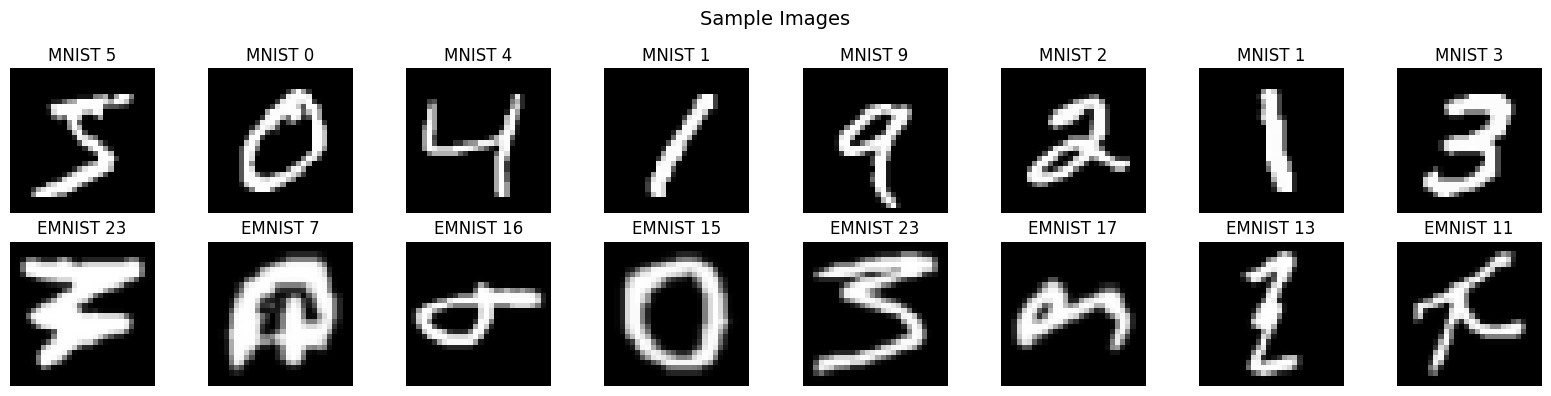

In [2]:
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

# MNIST
mnist_train = MNIST(root='./data', train=True,  download=True, transform=transform)
mnist_test  = MNIST(root='./data', train=False, download=True, transform=transform)

mnist_train_loader = DataLoader(mnist_train, batch_size=128, shuffle=True,  num_workers=2)
mnist_test_loader  = DataLoader(mnist_test,  batch_size=128, shuffle=False, num_workers=2)

# EMNIST-Letters (26 classes A-Z)
emnist_train = EMNIST(root='./data', split='letters', train=True,  download=True, transform=transform)
emnist_test  = EMNIST(root='./data', split='letters', train=False, download=True, transform=transform)

# Use a 10k subset of EMNIST for speed
emnist_train_sub = Subset(emnist_train, range(10000))
emnist_test_sub  = Subset(emnist_test,  range(2000))

emnist_train_loader = DataLoader(emnist_train_sub, batch_size=128, shuffle=True,  num_workers=2)
emnist_test_loader  = DataLoader(emnist_test_sub,  batch_size=128, shuffle=False, num_workers=2)

print(f'MNIST   — Train: {len(mnist_train):,}  Test: {len(mnist_test):,}')
print(f'EMNIST  — Train subset: {len(emnist_train_sub):,}  Test subset: {len(emnist_test_sub):,}')

# Visualise samples
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(8):
    axes[0, i].imshow(mnist_train[i][0].squeeze(), cmap='gray')
    axes[0, i].set_title(f'MNIST {mnist_train[i][1]}')
    axes[0, i].axis('off')
    axes[1, i].imshow(emnist_train[i][0].squeeze(), cmap='gray')
    axes[1, i].set_title(f'EMNIST {emnist_train[i][1]}')
    axes[1, i].axis('off')
plt.suptitle('Sample Images', fontsize=14)
plt.tight_layout()
plt.show()

## Helper: Training & Evaluation

In [3]:
def train_model(model, train_loader, test_loader, epochs=5,
                lr=0.001, clip=None, optimizer_name='adam'):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()

    if optimizer_name == 'adam':
        optimizer = optim.Adam(model.parameters(), lr=lr)
    elif optimizer_name == 'sgd':
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    elif optimizer_name == 'rmsprop':
        optimizer = optim.RMSprop(model.parameters(), lr=lr)
    else:
        optimizer = optim.AdamW(model.parameters(), lr=lr)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    total_train_time = 0

    for epoch in range(epochs):
        model.train()
        t0 = time.time()
        running_loss, correct, total = 0.0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            # Reshape: (B, 1, 28, 28) -> (B, 28, 28)
            imgs = imgs.squeeze(1)
            optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            if clip:
                nn.utils.clip_grad_norm_(model.parameters(), clip)
            optimizer.step()
            running_loss += loss.item() * imgs.size(0)
            correct += (out.argmax(1) == labels).sum().item()
            total   += imgs.size(0)
        epoch_time = time.time() - t0
        total_train_time += epoch_time

        train_loss = running_loss / total
        train_acc  = correct / total

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels in test_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                imgs = imgs.squeeze(1)
                out  = model(imgs)
                loss = criterion(out, labels)
                val_loss    += loss.item() * imgs.size(0)
                val_correct += (out.argmax(1) == labels).sum().item()
                val_total   += imgs.size(0)
        val_loss = val_loss / val_total
        val_acc  = val_correct / val_total

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        print(f'Epoch {epoch+1}/{epochs} | '
              f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | '
              f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | '
              f'Time: {epoch_time:.1f}s')

    history['total_train_time'] = total_train_time
    history['avg_epoch_time']   = total_train_time / epochs
    return history


def plot_curves(history, title=''):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history['train_loss'], label='Train')
    ax1.plot(history['val_loss'],   label='Val')
    ax1.set_title(f'{title} — Loss')
    ax1.set_xlabel('Epoch'); ax1.legend()
    ax2.plot(history['train_acc'], label='Train')
    ax2.plot(history['val_acc'],   label='Val')
    ax2.set_title(f'{title} — Accuracy')
    ax2.set_xlabel('Epoch'); ax2.legend()
    plt.tight_layout(); plt.show()


def evaluate_model(model, loader, num_classes):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.squeeze(1).to(device)
            preds = model(imgs).argmax(1).cpu()
            all_preds.extend(preds.numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_preds), np.array(all_labels)


def plot_confusion(preds, labels, title='Confusion Matrix'):
    cm = confusion_matrix(labels, preds)
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(cm, cmap='Blues')
    plt.colorbar(im)
    ax.set_title(title)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    plt.tight_layout(); plt.show()


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print('Helpers defined.')

Helpers defined.


---
## Problem Statement 1 — Vanilla RNN
### Task (a) — RNN from Scratch

Training Vanilla RNN (scratch) on MNIST...
Epoch 1/5 | Train Loss: 0.8904 Acc: 0.6913 | Val Loss: 0.4774 Acc: 0.8396 | Time: 10.3s
Epoch 2/5 | Train Loss: 0.4074 Acc: 0.8773 | Val Loss: 0.2885 Acc: 0.9172 | Time: 9.3s
Epoch 3/5 | Train Loss: 0.2900 Acc: 0.9187 | Val Loss: 0.2465 Acc: 0.9329 | Time: 9.3s
Epoch 4/5 | Train Loss: 0.2317 Acc: 0.9354 | Val Loss: 0.1923 Acc: 0.9478 | Time: 9.3s
Epoch 5/5 | Train Loss: 0.2001 Acc: 0.9441 | Val Loss: 0.1906 Acc: 0.9447 | Time: 9.3s


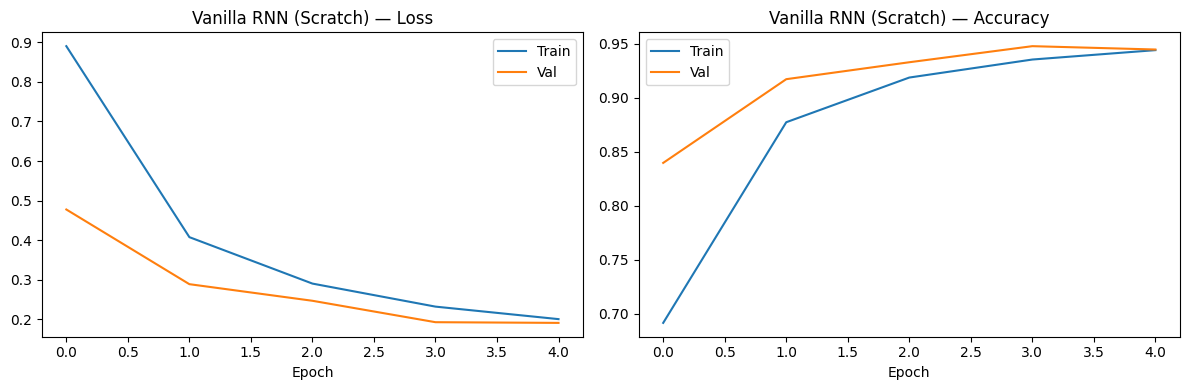


Training Vanilla RNN (PyTorch) on MNIST...
Epoch 1/5 | Train Loss: 0.9205 Acc: 0.6890 | Val Loss: 0.5171 Acc: 0.8342 | Time: 8.0s
Epoch 2/5 | Train Loss: 0.4135 Acc: 0.8769 | Val Loss: 0.2992 Acc: 0.9154 | Time: 7.8s
Epoch 3/5 | Train Loss: 0.2887 Acc: 0.9180 | Val Loss: 0.2255 Acc: 0.9387 | Time: 7.9s
Epoch 4/5 | Train Loss: 0.2239 Acc: 0.9369 | Val Loss: 0.2282 Acc: 0.9374 | Time: 7.8s
Epoch 5/5 | Train Loss: 0.1947 Acc: 0.9448 | Val Loss: 0.1863 Acc: 0.9486 | Time: 7.7s


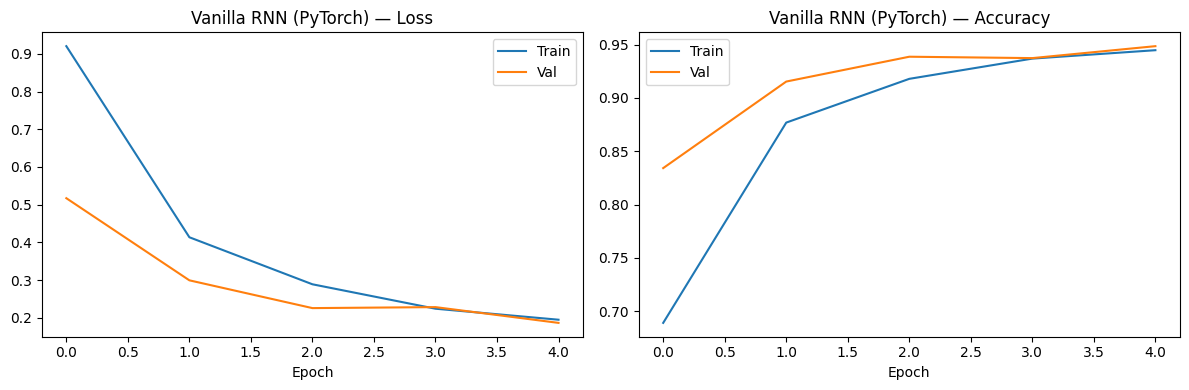

In [4]:
class VanillaRNNCell(nn.Module):
    """Single RNN cell implemented from scratch."""
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.Wxh = nn.Linear(input_size,  hidden_size, bias=False)
        self.Whh = nn.Linear(hidden_size, hidden_size, bias=True)

    def forward(self, x, h):
        return torch.tanh(self.Wxh(x) + self.Whh(h))


class VanillaRNNScratch(nn.Module):
    """Multi-layer Vanilla RNN built from scratch."""
    def __init__(self, input_size=28, hidden_size=128, num_layers=1, num_classes=10):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers
        self.cells = nn.ModuleList()
        for i in range(num_layers):
            inp = input_size if i == 0 else hidden_size
            self.cells.append(VanillaRNNCell(inp, hidden_size))
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # x: (batch, seq_len=28, input_size=28)
        B, T, _ = x.shape
        h = [torch.zeros(B, self.hidden_size, device=x.device) for _ in range(self.num_layers)]
        for t in range(T):
            inp = x[:, t, :]
            for l, cell in enumerate(self.cells):
                h[l] = cell(inp, h[l])
                inp = h[l]
        return self.fc(h[-1])


class VanillaRNNPyTorch(nn.Module):
    """Vanilla RNN using PyTorch's built-in nn.RNN."""
    def __init__(self, input_size=28, hidden_size=128, num_layers=1, num_classes=10):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc  = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out, _ = self.rnn(x)  # out: (B, T, H)
        return self.fc(out[:, -1, :])


print('Training Vanilla RNN (scratch) on MNIST...')
rnn_scratch = VanillaRNNScratch(hidden_size=128, num_layers=1)
hist_rnn_scratch = train_model(rnn_scratch, mnist_train_loader, mnist_test_loader, epochs=5)
plot_curves(hist_rnn_scratch, 'Vanilla RNN (Scratch)')

print('\nTraining Vanilla RNN (PyTorch) on MNIST...')
rnn_pt = VanillaRNNPyTorch(hidden_size=128, num_layers=1)
hist_rnn_pt = train_model(rnn_pt, mnist_train_loader, mnist_test_loader, epochs=5)
plot_curves(hist_rnn_pt, 'Vanilla RNN (PyTorch)')

### Task (b) — Vanishing Gradient Analysis

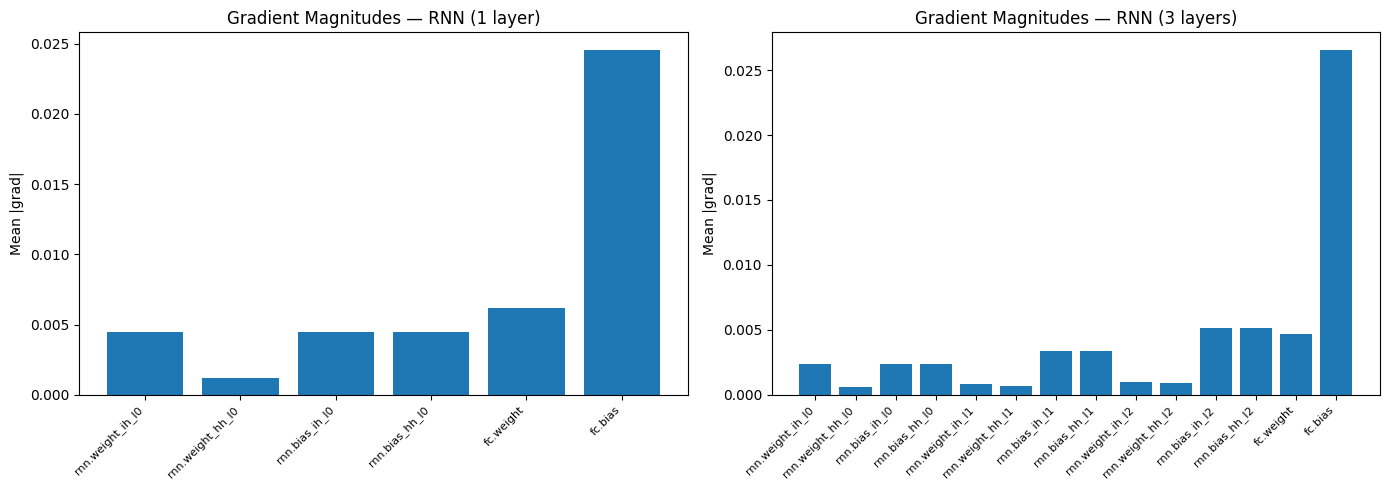

Observation: Deeper vanilla RNNs suffer from vanishing gradients (smaller magnitudes in earlier layers).


In [5]:
def compute_gradient_magnitudes(model, loader, num_batches=5):
    """Compute mean gradient magnitude per layer."""
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    grad_norms = {name: [] for name, _ in model.named_parameters()}

    model.train()
    for i, (imgs, labels) in enumerate(loader):
        if i >= num_batches:
            break
        imgs   = imgs.squeeze(1).to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(imgs), labels)
        loss.backward()
        for name, p in model.named_parameters():
            if p.grad is not None:
                grad_norms[name].append(p.grad.abs().mean().item())

    return {k: np.mean(v) for k, v in grad_norms.items() if v}


# Compare gradient magnitudes for 1-layer vs 3-layer RNN
models_grad = {
    'RNN (1 layer)': VanillaRNNPyTorch(hidden_size=128, num_layers=1),
    'RNN (3 layers)': VanillaRNNPyTorch(hidden_size=128, num_layers=3),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (name, mdl) in zip(axes, models_grad.items()):
    grads = compute_gradient_magnitudes(mdl, mnist_train_loader)
    ax.bar(range(len(grads)), list(grads.values()))
    ax.set_xticks(range(len(grads)))
    ax.set_xticklabels(list(grads.keys()), rotation=45, ha='right', fontsize=8)
    ax.set_title(f'Gradient Magnitudes — {name}')
    ax.set_ylabel('Mean |grad|')
plt.tight_layout()
plt.show()
print('Observation: Deeper vanilla RNNs suffer from vanishing gradients (smaller magnitudes in earlier layers).')

### Task (c) — Row-wise vs Column-wise Scanning

In [6]:
class RNNDirectional(nn.Module):
    def __init__(self, hidden_size=128, num_classes=10, direction='row'):
        super().__init__()
        self.direction = direction
        self.rnn = nn.RNN(28, hidden_size, batch_first=True)
        self.fc  = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # x: (B, 28, 28) — row-wise by default
        if self.direction == 'col':
            x = x.permute(0, 2, 1)  # transpose → column-wise
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])


print('Row-wise scanning:')
rnn_row = RNNDirectional(direction='row')
hist_row = train_model(rnn_row, mnist_train_loader, mnist_test_loader, epochs=5)

print('\nColumn-wise scanning:')
rnn_col = RNNDirectional(direction='col')
hist_col = train_model(rnn_col, mnist_train_loader, mnist_test_loader, epochs=5)

print(f'\nRow-wise final val acc : {hist_row["val_acc"][-1]:.4f}')
print(f'Column-wise final val acc: {hist_col["val_acc"][-1]:.4f}')

Row-wise scanning:
Epoch 1/5 | Train Loss: 0.8956 Acc: 0.7025 | Val Loss: 0.6017 Acc: 0.8150 | Time: 7.5s
Epoch 2/5 | Train Loss: 0.4142 Acc: 0.8788 | Val Loss: 0.3108 Acc: 0.9144 | Time: 7.6s
Epoch 3/5 | Train Loss: 0.2805 Acc: 0.9206 | Val Loss: 0.2270 Acc: 0.9395 | Time: 7.4s
Epoch 4/5 | Train Loss: 0.2179 Acc: 0.9385 | Val Loss: 0.2480 Acc: 0.9309 | Time: 7.5s
Epoch 5/5 | Train Loss: 0.1839 Acc: 0.9482 | Val Loss: 0.1631 Acc: 0.9561 | Time: 7.5s

Column-wise scanning:
Epoch 1/5 | Train Loss: 1.0280 Acc: 0.6615 | Val Loss: 0.4844 Acc: 0.8608 | Time: 7.5s
Epoch 2/5 | Train Loss: 0.4212 Acc: 0.8805 | Val Loss: 0.3974 Acc: 0.8833 | Time: 7.4s
Epoch 3/5 | Train Loss: 0.3108 Acc: 0.9120 | Val Loss: 0.2644 Acc: 0.9279 | Time: 7.4s
Epoch 4/5 | Train Loss: 0.2492 Acc: 0.9300 | Val Loss: 0.2063 Acc: 0.9410 | Time: 7.6s
Epoch 5/5 | Train Loss: 0.2136 Acc: 0.9399 | Val Loss: 0.2163 Acc: 0.9399 | Time: 7.6s

Row-wise final val acc : 0.9561
Column-wise final val acc: 0.9399


### Task (d) — Accuracy, Loss & Training Time (varying hidden units & layers)

In [7]:
rnn_configs = [
    {'hidden': 64,  'layers': 1},
    {'hidden': 128, 'layers': 1},
    {'hidden': 256, 'layers': 1},
    {'hidden': 128, 'layers': 2},
    {'hidden': 128, 'layers': 3},
]

rnn_results = {}
for cfg in rnn_configs:
    label = f"h={cfg['hidden']} l={cfg['layers']}"
    print(f'\n--- RNN {label} ---')
    m = VanillaRNNPyTorch(hidden_size=cfg['hidden'], num_layers=cfg['layers'])
    h = train_model(m, mnist_train_loader, mnist_test_loader, epochs=5)
    rnn_results[label] = {
        'val_acc': h['val_acc'][-1],
        'train_time': h['avg_epoch_time'],
        'params': count_parameters(m),
    }

print('\n=== RNN Config Summary ===')
print(f'{"Config":<18} {"Val Acc":>10} {"Params":>10} {"Avg Epoch (s)":>15}')
for k, v in rnn_results.items():
    print(f'{k:<18} {v["val_acc"]:>10.4f} {v["params"]:>10,} {v["train_time"]:>15.2f}')


--- RNN h=64 l=1 ---
Epoch 1/5 | Train Loss: 1.0939 Acc: 0.6257 | Val Loss: 0.6658 Acc: 0.7799 | Time: 7.4s
Epoch 2/5 | Train Loss: 0.5435 Acc: 0.8289 | Val Loss: 0.4589 Acc: 0.8615 | Time: 7.5s
Epoch 3/5 | Train Loss: 0.4035 Acc: 0.8818 | Val Loss: 0.3556 Acc: 0.8944 | Time: 7.4s
Epoch 4/5 | Train Loss: 0.3221 Acc: 0.9064 | Val Loss: 0.2912 Acc: 0.9141 | Time: 7.5s
Epoch 5/5 | Train Loss: 0.2756 Acc: 0.9206 | Val Loss: 0.2519 Acc: 0.9257 | Time: 7.6s

--- RNN h=128 l=1 ---
Epoch 1/5 | Train Loss: 0.9396 Acc: 0.6828 | Val Loss: 0.4969 Acc: 0.8523 | Time: 7.4s
Epoch 2/5 | Train Loss: 0.4014 Acc: 0.8800 | Val Loss: 0.3097 Acc: 0.9125 | Time: 7.5s
Epoch 3/5 | Train Loss: 0.2691 Acc: 0.9219 | Val Loss: 0.2235 Acc: 0.9345 | Time: 7.4s
Epoch 4/5 | Train Loss: 0.2156 Acc: 0.9382 | Val Loss: 0.1758 Acc: 0.9504 | Time: 7.3s
Epoch 5/5 | Train Loss: 0.1864 Acc: 0.9468 | Val Loss: 0.1919 Acc: 0.9459 | Time: 7.6s

--- RNN h=256 l=1 ---
Epoch 1/5 | Train Loss: 0.7049 Acc: 0.7674 | Val Loss: 0.3175 

---
## Problem Statement 2 — LSTM
### Task (e) — Single & Multi-layer LSTM

Training single-layer LSTM...
Epoch 1/5 | Train Loss: 0.5238 Acc: 0.8322 | Val Loss: 0.1802 Acc: 0.9435 | Time: 7.4s
Epoch 2/5 | Train Loss: 0.1349 Acc: 0.9593 | Val Loss: 0.1184 Acc: 0.9653 | Time: 7.5s
Epoch 3/5 | Train Loss: 0.0933 Acc: 0.9716 | Val Loss: 0.0946 Acc: 0.9721 | Time: 7.6s
Epoch 4/5 | Train Loss: 0.0738 Acc: 0.9778 | Val Loss: 0.0636 Acc: 0.9811 | Time: 7.5s
Epoch 5/5 | Train Loss: 0.0586 Acc: 0.9825 | Val Loss: 0.0682 Acc: 0.9790 | Time: 7.7s


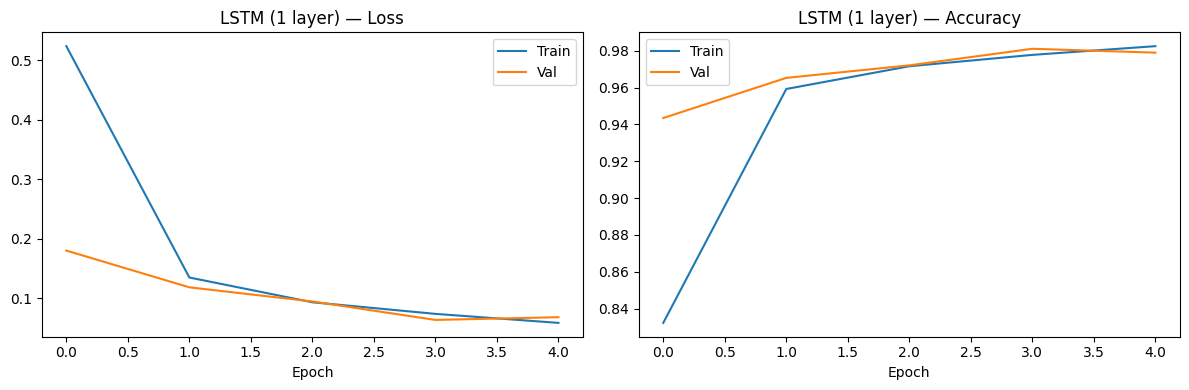


Training 2-layer LSTM...
Epoch 1/5 | Train Loss: 0.4755 Acc: 0.8429 | Val Loss: 0.1334 Acc: 0.9608 | Time: 7.9s
Epoch 2/5 | Train Loss: 0.1127 Acc: 0.9661 | Val Loss: 0.0762 Acc: 0.9776 | Time: 7.9s
Epoch 3/5 | Train Loss: 0.0687 Acc: 0.9797 | Val Loss: 0.0747 Acc: 0.9789 | Time: 7.8s
Epoch 4/5 | Train Loss: 0.0551 Acc: 0.9837 | Val Loss: 0.0492 Acc: 0.9851 | Time: 7.7s
Epoch 5/5 | Train Loss: 0.0420 Acc: 0.9873 | Val Loss: 0.0503 Acc: 0.9862 | Time: 7.6s


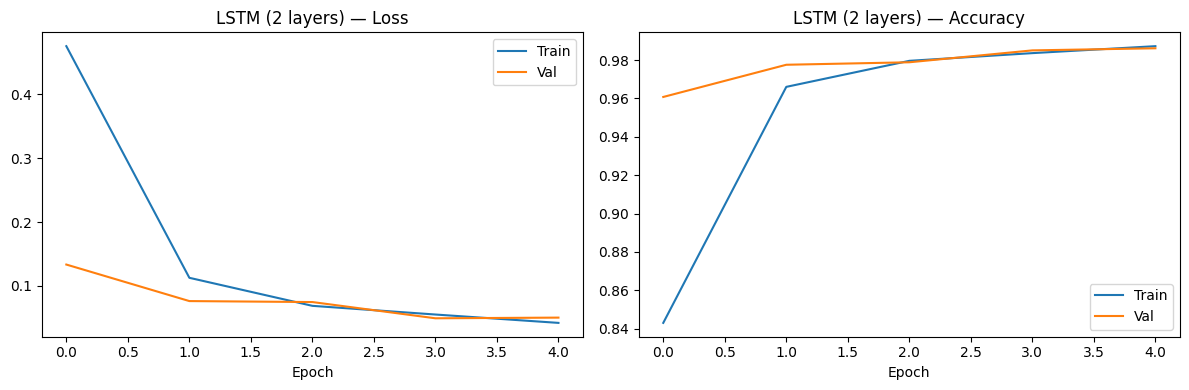

In [8]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=28, hidden_size=128, num_layers=1,
                 num_classes=10, dropout=0.0):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            batch_first=True,
                            dropout=dropout if num_layers > 1 else 0.0)
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out, (hn, _) = self.lstm(x)
        return self.fc(self.dropout(hn[-1]))


print('Training single-layer LSTM...')
lstm1 = LSTMModel(hidden_size=128, num_layers=1)
hist_lstm1 = train_model(lstm1, mnist_train_loader, mnist_test_loader, epochs=5)
plot_curves(hist_lstm1, 'LSTM (1 layer)')

print('\nTraining 2-layer LSTM...')
lstm2 = LSTMModel(hidden_size=128, num_layers=2)
hist_lstm2 = train_model(lstm2, mnist_train_loader, mnist_test_loader, epochs=5)
plot_curves(hist_lstm2, 'LSTM (2 layers)')

### Task (f) — Visualize Gate Activations

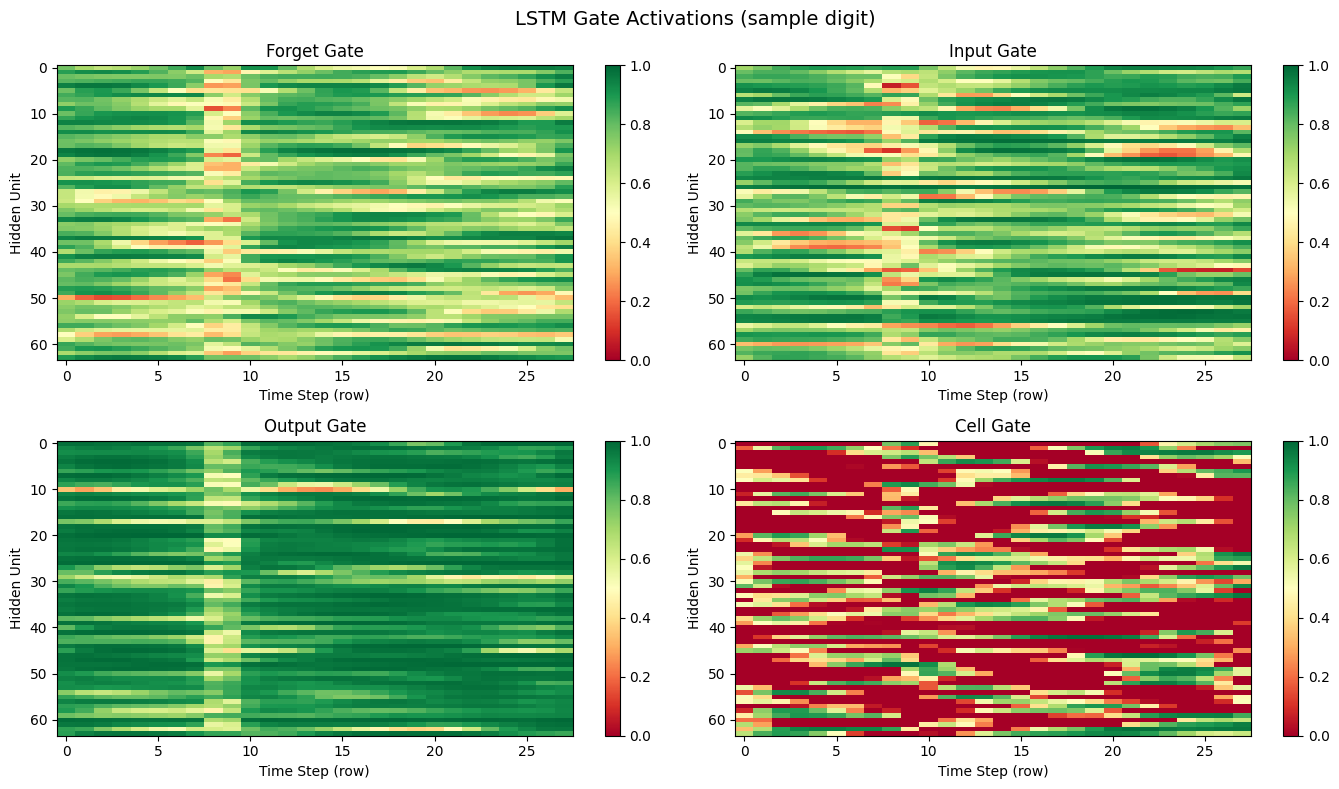

In [9]:
class LSTMWithGates(nn.Module):
    """LSTM that stores gate activations for a single sample."""
    def __init__(self, input_size=28, hidden_size=64, num_classes=10):
        super().__init__()
        self.hidden_size = hidden_size
        self.lstm_cell   = nn.LSTMCell(input_size, hidden_size)
        self.fc          = nn.Linear(hidden_size, num_classes)
        self.gate_history = {'forget': [], 'input': [], 'output': [], 'cell': []}

    def forward(self, x, record_gates=False):
        B, T, _ = x.shape
        h = torch.zeros(B, self.hidden_size, device=x.device)
        c = torch.zeros(B, self.hidden_size, device=x.device)
        if record_gates:
            self.gate_history = {'forget': [], 'input': [], 'output': [], 'cell': []}
        for t in range(T):
            h, c = self.lstm_cell(x[:, t, :], (h, c))
            if record_gates:
                # Manually compute gates for visualisation (first sample)
                with torch.no_grad():
                    combined = torch.cat([x[0:1, t, :], h[0:1]], dim=1)
                    W = self.lstm_cell.weight_ih
                    U = self.lstm_cell.weight_hh
                    b = self.lstm_cell.bias_ih + self.lstm_cell.bias_hh
                    gates_raw = (x[0:1, t, :] @ W.T + h[0:1] @ U.T + b)
                    H = self.hidden_size
                    i_g = torch.sigmoid(gates_raw[:, :H]).squeeze()
                    f_g = torch.sigmoid(gates_raw[:, H:2*H]).squeeze()
                    g_g = torch.tanh(gates_raw[:, 2*H:3*H]).squeeze()
                    o_g = torch.sigmoid(gates_raw[:, 3*H:]).squeeze()
                    self.gate_history['forget'].append(f_g.cpu().numpy())
                    self.gate_history['input'].append(i_g.cpu().numpy())
                    self.gate_history['output'].append(o_g.cpu().numpy())
                    self.gate_history['cell'].append(g_g.cpu().numpy())
        return self.fc(h)


# Train briefly
gate_model = LSTMWithGates(hidden_size=64).to(device)
criterion = nn.CrossEntropyLoss()
opt = optim.Adam(gate_model.parameters(), lr=0.001)
gate_model.train()
for imgs, labels in mnist_train_loader:
    imgs   = imgs.squeeze(1).to(device)
    labels = labels.to(device)
    opt.zero_grad()
    criterion(gate_model(imgs), labels).backward()
    opt.step()

# Record gates on one sample
sample_img = mnist_test[0][0].unsqueeze(0).squeeze(1).to(device)  # (1,28,28)
gate_model.eval()
with torch.no_grad():
    gate_model(sample_img, record_gates=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
gate_names = ['forget', 'input', 'output', 'cell']
for ax, gname in zip(axes.flat, gate_names):
    mat = np.array(gate_model.gate_history[gname])  # (28, 64)
    im = ax.imshow(mat.T, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
    ax.set_title(f'{gname.capitalize()} Gate')
    ax.set_xlabel('Time Step (row)'); ax.set_ylabel('Hidden Unit')
    plt.colorbar(im, ax=ax)
plt.suptitle('LSTM Gate Activations (sample digit)', fontsize=14)
plt.tight_layout()
plt.show()

### Task (g, h, i) — Hidden Units, Dropout, RNN Comparison

In [10]:
lstm_configs = [
    {'hidden': 32,  'dropout': 0.0, 'label': 'h=32  dp=0.0'},
    {'hidden': 64,  'dropout': 0.0, 'label': 'h=64  dp=0.0'},
    {'hidden': 128, 'dropout': 0.0, 'label': 'h=128 dp=0.0'},
    {'hidden': 256, 'dropout': 0.0, 'label': 'h=256 dp=0.0'},
    {'hidden': 128, 'dropout': 0.2, 'label': 'h=128 dp=0.2'},
    {'hidden': 128, 'dropout': 0.3, 'label': 'h=128 dp=0.3'},
    {'hidden': 128, 'dropout': 0.5, 'label': 'h=128 dp=0.5'},
]

lstm_results = {}
for cfg in lstm_configs:
    print(f'\n--- LSTM {cfg["label"]} ---')
    m = LSTMModel(hidden_size=cfg['hidden'], dropout=cfg['dropout'], num_layers=2)
    h = train_model(m, mnist_train_loader, mnist_test_loader, epochs=5)
    lstm_results[cfg['label']] = {
        'val_acc': h['val_acc'][-1],
        'train_time': h['avg_epoch_time'],
        'params': count_parameters(m),
        'history': h,
    }

print('\n=== LSTM Config Summary ===')
print(f'{"Config":<20} {"Val Acc":>10} {"Params":>10} {"Avg Epoch (s)":>15}')
for k, v in lstm_results.items():
    print(f'{k:<20} {v["val_acc"]:>10.4f} {v["params"]:>10,} {v["train_time"]:>15.2f}')


--- LSTM h=32  dp=0.0 ---
Epoch 1/5 | Train Loss: 0.9162 Acc: 0.7027 | Val Loss: 0.2883 Acc: 0.9194 | Time: 7.4s
Epoch 2/5 | Train Loss: 0.2292 Acc: 0.9351 | Val Loss: 0.1573 Acc: 0.9563 | Time: 7.5s
Epoch 3/5 | Train Loss: 0.1517 Acc: 0.9573 | Val Loss: 0.1296 Acc: 0.9622 | Time: 7.9s
Epoch 4/5 | Train Loss: 0.1203 Acc: 0.9659 | Val Loss: 0.1131 Acc: 0.9670 | Time: 7.6s
Epoch 5/5 | Train Loss: 0.1035 Acc: 0.9702 | Val Loss: 0.1009 Acc: 0.9703 | Time: 7.4s

--- LSTM h=64  dp=0.0 ---
Epoch 1/5 | Train Loss: 0.5777 Acc: 0.8146 | Val Loss: 0.1791 Acc: 0.9468 | Time: 7.6s
Epoch 2/5 | Train Loss: 0.1493 Acc: 0.9560 | Val Loss: 0.1087 Acc: 0.9672 | Time: 7.5s
Epoch 3/5 | Train Loss: 0.1023 Acc: 0.9694 | Val Loss: 0.0933 Acc: 0.9717 | Time: 7.4s
Epoch 4/5 | Train Loss: 0.0830 Acc: 0.9745 | Val Loss: 0.0913 Acc: 0.9731 | Time: 7.4s
Epoch 5/5 | Train Loss: 0.0690 Acc: 0.9798 | Val Loss: 0.0737 Acc: 0.9776 | Time: 7.6s

--- LSTM h=128 dp=0.0 ---
Epoch 1/5 | Train Loss: 0.4742 Acc: 0.8451 | Val 

---
## Problem Statement 3 — GRU
### Tasks (j, k, l, m)

In [11]:
class GRUModel(nn.Module):
    def __init__(self, input_size=28, hidden_size=128, num_layers=1, num_classes=10, dropout=0.0):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True,
                          dropout=dropout if num_layers > 1 else 0.0)
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out, hn = self.gru(x)
        return self.fc(self.dropout(hn[-1]))


gru_configs = [
    {'layers': 1, 'label': 'GRU 1L'},
    {'layers': 2, 'label': 'GRU 2L'},
    {'layers': 3, 'label': 'GRU 3L'},
]

gru_results = {}
for cfg in gru_configs:
    print(f'\n--- {cfg["label"]} ---')
    m = GRUModel(hidden_size=128, num_layers=cfg['layers'])
    h = train_model(m, mnist_train_loader, mnist_test_loader, epochs=5)
    gru_results[cfg['label']] = {
        'val_acc': h['val_acc'][-1],
        'train_time': h['avg_epoch_time'],
        'params': count_parameters(m),
    }

# GRU vs LSTM comparison (1 layer)
print('\n=== GRU vs LSTM Comparison (1 layer, h=128) ===')
lstm_ref = LSTMModel(hidden_size=128, num_layers=1)
gru_ref  = GRUModel(hidden_size=128,  num_layers=1)
print(f'LSTM params : {count_parameters(lstm_ref):,}')
print(f'GRU  params : {count_parameters(gru_ref):,}')
print(f'GRU has ~{(count_parameters(lstm_ref)-count_parameters(gru_ref))/count_parameters(lstm_ref)*100:.1f}% fewer parameters than LSTM')

print('\n=== GRU Config Summary ===')
print(f'{"Config":<12} {"Val Acc":>10} {"Params":>10} {"Avg Epoch (s)":>15}')
for k, v in gru_results.items():
    print(f'{k:<12} {v["val_acc"]:>10.4f} {v["params"]:>10,} {v["train_time"]:>15.2f}')

print("""
When to prefer GRU over LSTM:
  - Smaller datasets / limited compute  → GRU converges faster with fewer params
  - Shorter sequences                   → GRU's simpler gating is sufficient
  - Need faster inference               → GRU has lower FLOPs
  LSTM is preferred when long-range dependencies matter or you have large data.
""")


--- GRU 1L ---
Epoch 1/5 | Train Loss: 0.6156 Acc: 0.7998 | Val Loss: 0.1818 Acc: 0.9447 | Time: 7.4s
Epoch 2/5 | Train Loss: 0.1396 Acc: 0.9590 | Val Loss: 0.1040 Acc: 0.9711 | Time: 7.3s
Epoch 3/5 | Train Loss: 0.0911 Acc: 0.9723 | Val Loss: 0.0814 Acc: 0.9765 | Time: 7.4s
Epoch 4/5 | Train Loss: 0.0686 Acc: 0.9789 | Val Loss: 0.0720 Acc: 0.9785 | Time: 7.6s
Epoch 5/5 | Train Loss: 0.0559 Acc: 0.9832 | Val Loss: 0.0634 Acc: 0.9806 | Time: 7.4s

--- GRU 2L ---
Epoch 1/5 | Train Loss: 0.4672 Acc: 0.8437 | Val Loss: 0.1224 Acc: 0.9646 | Time: 7.7s
Epoch 2/5 | Train Loss: 0.0989 Acc: 0.9701 | Val Loss: 0.0810 Acc: 0.9747 | Time: 7.7s
Epoch 3/5 | Train Loss: 0.0673 Acc: 0.9790 | Val Loss: 0.0539 Acc: 0.9832 | Time: 7.6s
Epoch 4/5 | Train Loss: 0.0518 Acc: 0.9840 | Val Loss: 0.0455 Acc: 0.9860 | Time: 7.6s
Epoch 5/5 | Train Loss: 0.0388 Acc: 0.9879 | Val Loss: 0.0440 Acc: 0.9868 | Time: 7.6s

--- GRU 3L ---
Epoch 1/5 | Train Loss: 0.4125 Acc: 0.8644 | Val Loss: 0.1291 Acc: 0.9589 | Time: 

---
## Problem Statement 4 — Bidirectional LSTM
### Tasks (n, o, p, q)

In [12]:
class BiLSTMModel(nn.Module):
    def __init__(self, input_size=28, hidden_size=128, num_layers=1,
                 num_classes=10, merge='concat'):
        super().__init__()
        self.merge = merge
        self.lstm  = nn.LSTM(input_size, hidden_size, num_layers,
                             batch_first=True, bidirectional=True)
        fc_in = hidden_size * 2 if merge == 'concat' else hidden_size
        self.fc = nn.Linear(fc_in, num_classes)

    def forward(self, x):
        _, (hn, _) = self.lstm(x)   # hn: (2*layers, B, H)
        fwd = hn[-2]                # last forward  hidden
        bwd = hn[-1]                # last backward hidden
        if self.merge == 'concat':
            out = torch.cat([fwd, bwd], dim=1)
        else:
            out = (fwd + bwd) / 2
        return self.fc(out)


class BiGRUModel(nn.Module):
    def __init__(self, input_size=28, hidden_size=128, num_classes=10):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, batch_first=True, bidirectional=True)
        self.fc  = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        _, hn = self.gru(x)
        return self.fc(torch.cat([hn[-2], hn[-1]], dim=1))


bilstm_concat = BiLSTMModel(hidden_size=128, merge='concat')
bilstm_avg    = BiLSTMModel(hidden_size=128, merge='avg')
lstm_uni      = LSTMModel(hidden_size=128, num_layers=1)
bigru         = BiGRUModel(hidden_size=128)

print('BiLSTM (concat):')
hist_bilstm_c = train_model(bilstm_concat, mnist_train_loader, mnist_test_loader, epochs=5)

print('\nBiLSTM (average):')
hist_bilstm_a = train_model(bilstm_avg, mnist_train_loader, mnist_test_loader, epochs=5)

print('\nUnidirectional LSTM:')
hist_uni = train_model(lstm_uni, mnist_train_loader, mnist_test_loader, epochs=5)

print('\nBiGRU:')
hist_bigru = train_model(bigru, mnist_train_loader, mnist_test_loader, epochs=5)

print('\n=== Bidirectional Comparison ===')
for name, hist in [('BiLSTM Concat', hist_bilstm_c), ('BiLSTM Avg', hist_bilstm_a),
                   ('UniLSTM', hist_uni), ('BiGRU', hist_bigru)]:
    print(f'{name:<18} Val Acc: {hist["val_acc"][-1]:.4f}')

print("""
Observation: Bidirectional models see both the top and bottom of the digit.
For row-wise image scanning this gives marginal improvement since digits
are not inherently causal sequences.
""")

BiLSTM (concat):
Epoch 1/5 | Train Loss: 0.4822 Acc: 0.8440 | Val Loss: 0.1336 Acc: 0.9590 | Time: 7.6s
Epoch 2/5 | Train Loss: 0.1113 Acc: 0.9657 | Val Loss: 0.1015 Acc: 0.9706 | Time: 7.6s
Epoch 3/5 | Train Loss: 0.0768 Acc: 0.9770 | Val Loss: 0.0765 Acc: 0.9766 | Time: 7.6s
Epoch 4/5 | Train Loss: 0.0579 Acc: 0.9825 | Val Loss: 0.0679 Acc: 0.9792 | Time: 7.6s
Epoch 5/5 | Train Loss: 0.0473 Acc: 0.9854 | Val Loss: 0.0577 Acc: 0.9825 | Time: 7.6s

BiLSTM (average):
Epoch 1/5 | Train Loss: 0.5277 Acc: 0.8318 | Val Loss: 0.1518 Acc: 0.9554 | Time: 7.6s
Epoch 2/5 | Train Loss: 0.1190 Acc: 0.9641 | Val Loss: 0.1066 Acc: 0.9671 | Time: 7.7s
Epoch 3/5 | Train Loss: 0.0801 Acc: 0.9754 | Val Loss: 0.0888 Acc: 0.9726 | Time: 7.6s
Epoch 4/5 | Train Loss: 0.0639 Acc: 0.9805 | Val Loss: 0.0750 Acc: 0.9781 | Time: 7.7s
Epoch 5/5 | Train Loss: 0.0531 Acc: 0.9838 | Val Loss: 0.0590 Acc: 0.9834 | Time: 7.7s

Unidirectional LSTM:
Epoch 1/5 | Train Loss: 0.5308 Acc: 0.8285 | Val Loss: 0.1427 Acc: 0.958

---
## Problem Statement 5 — CNN + LSTM Hybrid
### Tasks (r, s, t, u)

CNN+LSTM Hybrid (Architecture A):
Epoch 1/5 | Train Loss: 1.0455 Acc: 0.6257 | Val Loss: 0.4668 Acc: 0.8410 | Time: 14.4s
Epoch 2/5 | Train Loss: 0.3871 Acc: 0.8640 | Val Loss: 0.3208 Acc: 0.8877 | Time: 14.5s
Epoch 3/5 | Train Loss: 0.2805 Acc: 0.9027 | Val Loss: 0.2355 Acc: 0.9180 | Time: 14.9s
Epoch 4/5 | Train Loss: 0.2276 Acc: 0.9213 | Val Loss: 0.2211 Acc: 0.9253 | Time: 15.3s
Epoch 5/5 | Train Loss: 0.2023 Acc: 0.9300 | Val Loss: 0.1843 Acc: 0.9377 | Time: 15.1s


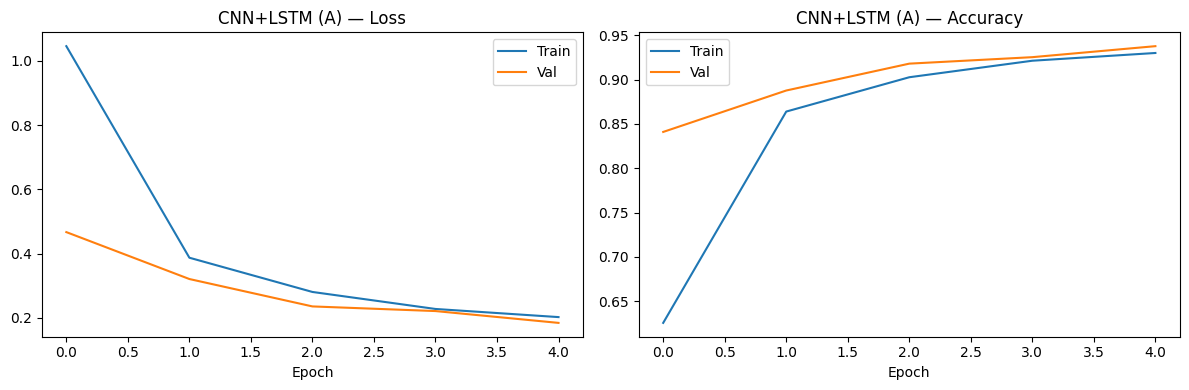


Time-Distributed CNN + LSTM (Architecture B):
Epoch 1/5 | Train Loss: 0.5242 Acc: 0.8205 | Val Loss: 0.1338 Acc: 0.9596 | Time: 8.1s
Epoch 2/5 | Train Loss: 0.1115 Acc: 0.9666 | Val Loss: 0.0890 Acc: 0.9731 | Time: 8.1s
Epoch 3/5 | Train Loss: 0.0788 Acc: 0.9762 | Val Loss: 0.0801 Acc: 0.9745 | Time: 8.0s
Epoch 4/5 | Train Loss: 0.0580 Acc: 0.9822 | Val Loss: 0.0544 Acc: 0.9840 | Time: 7.8s
Epoch 5/5 | Train Loss: 0.0516 Acc: 0.9843 | Val Loss: 0.0582 Acc: 0.9810 | Time: 7.9s


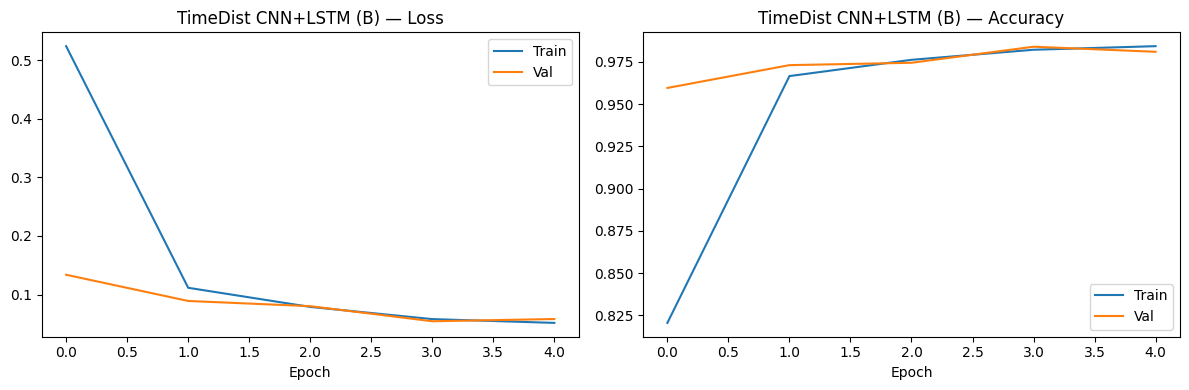


Pure CNN baseline:
Epoch 1/5 | Train Loss: 0.2027 Acc: 0.9426 | Val Loss: 0.0524 Acc: 0.9826 | Time: 7.9s
Epoch 2/5 | Train Loss: 0.0510 Acc: 0.9844 | Val Loss: 0.0405 Acc: 0.9862 | Time: 7.8s
Epoch 3/5 | Train Loss: 0.0354 Acc: 0.9891 | Val Loss: 0.0335 Acc: 0.9885 | Time: 7.7s
Epoch 4/5 | Train Loss: 0.0275 Acc: 0.9918 | Val Loss: 0.0394 Acc: 0.9878 | Time: 7.9s
Epoch 5/5 | Train Loss: 0.0195 Acc: 0.9938 | Val Loss: 0.0370 Acc: 0.9885 | Time: 7.7s

Pure LSTM baseline (h=128):
Epoch 1/5 | Train Loss: 0.5401 Acc: 0.8238 | Val Loss: 0.1848 Acc: 0.9449 | Time: 7.7s
Epoch 2/5 | Train Loss: 0.1323 Acc: 0.9607 | Val Loss: 0.1140 Acc: 0.9671 | Time: 7.7s
Epoch 3/5 | Train Loss: 0.0904 Acc: 0.9727 | Val Loss: 0.0948 Acc: 0.9724 | Time: 7.8s
Epoch 4/5 | Train Loss: 0.0675 Acc: 0.9798 | Val Loss: 0.0763 Acc: 0.9770 | Time: 7.7s
Epoch 5/5 | Train Loss: 0.0565 Acc: 0.9828 | Val Loss: 0.0696 Acc: 0.9784 | Time: 7.8s

=== Hybrid Architecture Summary ===
Model                     Val Acc     Params

In [15]:
# Architecture A: CNN Feature Extractor + LSTM
class CNNLSTMModel(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=3, padding=1), nn.ReLU(),
        )
        self.lstm = nn.LSTM(64, 128, batch_first=True)
        self.fc   = nn.Linear(128, num_classes)

    def forward(self, x):
        B, T, F = x.shape
        x_cnn = x.reshape(B * T, 1, F)
        feats  = self.cnn(x_cnn)
        feats  = feats.mean(-1)
        feats  = feats.reshape(B, T, 64)
        out, (hn, _) = self.lstm(feats)
        return self.fc(hn[-1])


# Architecture B: Time-Distributed CNN + LSTM
class TimedistCNNLSTM(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 16, 3, padding=1)
        self.conv2 = nn.Conv1d(16, 32, 3, padding=1)
        self.pool  = nn.AdaptiveAvgPool1d(8)
        self.lstm  = nn.LSTM(32 * 8, 128, batch_first=True)
        self.fc    = nn.Linear(128, num_classes)

    def forward(self, x):
        B, T, F = x.shape
        x_td = x.reshape(B * T, 1, F)
        x_td = torch.relu(self.conv1(x_td))
        x_td = torch.relu(self.conv2(x_td))
        x_td = self.pool(x_td)
        x_td = x_td.reshape(B, T, -1)
        _, (hn, _) = self.lstm(x_td)
        return self.fc(hn[-1])


# Pure CNN baseline
class PureCNNForward(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool  = nn.MaxPool2d(2)
        self.fc1   = nn.Linear(64 * 7 * 7, 128)
        self.fc2   = nn.Linear(128, num_classes)

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.flatten(1)
        x = torch.relu(self.fc1(x))
        return self.fc2(x)


# ^^^ DELETE the second PureCNNForward class that was below this ^^^

print('CNN+LSTM Hybrid (Architecture A):')
cnn_lstm_a = CNNLSTMModel()
hist_cnn_lstm_a = train_model(cnn_lstm_a, mnist_train_loader, mnist_test_loader, epochs=5)
plot_curves(hist_cnn_lstm_a, 'CNN+LSTM (A)')

print('\nTime-Distributed CNN + LSTM (Architecture B):')
cnn_lstm_b = TimedistCNNLSTM()
hist_cnn_lstm_b = train_model(cnn_lstm_b, mnist_train_loader, mnist_test_loader, epochs=5)
plot_curves(hist_cnn_lstm_b, 'TimeDist CNN+LSTM (B)')

print('\nPure CNN baseline:')
pure_cnn = PureCNNForward()
hist_cnn = train_model(pure_cnn, mnist_train_loader, mnist_test_loader, epochs=5)

print('\nPure LSTM baseline (h=128):')
pure_lstm = LSTMModel(hidden_size=128)
hist_pure_lstm = train_model(pure_lstm, mnist_train_loader, mnist_test_loader, epochs=5)

print('\n=== Hybrid Architecture Summary ===')
hybrid_rows = [
    ('CNN+LSTM (A)',       hist_cnn_lstm_a,  cnn_lstm_a),
    ('TimeDist+LSTM (B)', hist_cnn_lstm_b,  cnn_lstm_b),
    ('Pure CNN',          hist_cnn,         pure_cnn),
    ('Pure LSTM',         hist_pure_lstm,   pure_lstm),
]
print(f'{"Model":<22} {"Val Acc":>10} {"Params":>10} {"Avg Epoch (s)":>15}')
for name, hist, mdl in hybrid_rows:
    print(f'{name:<22} {hist["val_acc"][-1]:>10.4f} {count_parameters(mdl):>10,} {hist["avg_epoch_time"]:>15.2f}')

---
## Problem Statement 6 — Hyperparameter Tuning & Regularization

Epoch 1/3 | Train Loss: 1.5351 Acc: 0.4505 | Val Loss: 0.7803 Acc: 0.7351 | Time: 1.8s
Epoch 2/3 | Train Loss: 0.5073 Acc: 0.8439 | Val Loss: 0.3641 Acc: 0.8892 | Time: 1.7s
Epoch 3/3 | Train Loss: 0.3011 Acc: 0.9163 | Val Loss: 0.3335 Acc: 0.9012 | Time: 1.8s
lr=0.01 adam         val_acc=0.9012
Epoch 1/3 | Train Loss: 1.9063 Acc: 0.3430 | Val Loss: 1.1045 Acc: 0.6623 | Time: 1.8s
Epoch 2/3 | Train Loss: 0.6852 Acc: 0.7917 | Val Loss: 0.4769 Acc: 0.8526 | Time: 1.7s
Epoch 3/3 | Train Loss: 0.3758 Acc: 0.8865 | Val Loss: 0.3321 Acc: 0.9006 | Time: 1.7s
lr=0.001 adam        val_acc=0.9006
Epoch 1/3 | Train Loss: 2.2992 Acc: 0.1092 | Val Loss: 2.2920 Acc: 0.1177 | Time: 1.8s
Epoch 2/3 | Train Loss: 2.2786 Acc: 0.1339 | Val Loss: 2.2447 Acc: 0.1579 | Time: 1.7s
Epoch 3/3 | Train Loss: 2.0436 Acc: 0.3115 | Val Loss: 1.7797 Acc: 0.4370 | Time: 1.7s
lr=0.0001 adam       val_acc=0.4370
Epoch 1/3 | Train Loss: 2.3083 Acc: 0.0994 | Val Loss: 2.3056 Acc: 0.1009 | Time: 1.8s
Epoch 2/3 | Train Loss

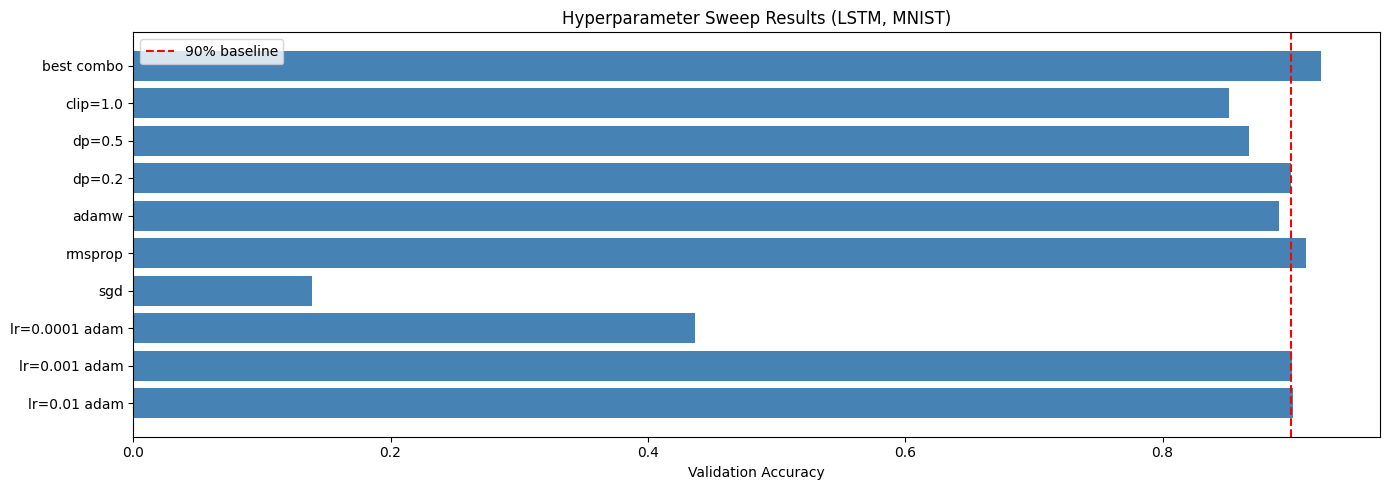

In [16]:
# Subset for speed
from torch.utils.data import Subset
small_train = Subset(mnist_train, range(8000))
small_loader = DataLoader(small_train, batch_size=128, shuffle=True)

sweep_configs = [
    # (lr, batch_size, hidden, layers, dropout, optimizer, clip, label)
    (0.01,   128, 128, 1, 0.0,  'adam',    None, 'lr=0.01 adam'),
    (0.001,  128, 128, 1, 0.0,  'adam',    None, 'lr=0.001 adam'),
    (0.0001, 128, 128, 1, 0.0,  'adam',    None, 'lr=0.0001 adam'),
    (0.001,  128, 128, 1, 0.0,  'sgd',     None, 'sgd'),
    (0.001,  128, 128, 1, 0.0,  'rmsprop', None, 'rmsprop'),
    (0.001,  128, 128, 1, 0.0,  'adamw',   None, 'adamw'),
    (0.001,  128, 128, 1, 0.2,  'adam',    None, 'dp=0.2'),
    (0.001,  128, 128, 1, 0.5,  'adam',    None, 'dp=0.5'),
    (0.001,  128, 128, 1, 0.0,  'adam',    1.0,  'clip=1.0'),
    (0.001,  128, 256, 2, 0.3,  'adamw',   1.0,  'best combo'),
]

hp_results = {}
for lr, bs, hidden, layers, dropout, opt_name, clip, label in sweep_configs:
    loader = DataLoader(small_train, batch_size=bs, shuffle=True)
    m = LSTMModel(hidden_size=hidden, num_layers=layers, dropout=dropout)
    h = train_model(m, loader, mnist_test_loader, epochs=3,
                    lr=lr, clip=clip, optimizer_name=opt_name)
    hp_results[label] = h['val_acc'][-1]
    print(f'{label:<20} val_acc={h["val_acc"][-1]:.4f}')

# Plot
fig, ax = plt.subplots(figsize=(14, 5))
ax.barh(list(hp_results.keys()), list(hp_results.values()), color='steelblue')
ax.set_xlabel('Validation Accuracy')
ax.set_title('Hyperparameter Sweep Results (LSTM, MNIST)')
ax.axvline(0.9, color='red', linestyle='--', label='90% baseline')
ax.legend()
plt.tight_layout()
plt.show()

### Early Stopping & LR Scheduling

Epoch  1 | val_acc=0.6676 | lr=0.001000
Epoch  2 | val_acc=0.8583 | lr=0.001000
Epoch  3 | val_acc=0.9030 | lr=0.001000
Epoch  4 | val_acc=0.9048 | lr=0.001000
Epoch  5 | val_acc=0.9401 | lr=0.001000
Epoch  6 | val_acc=0.9472 | lr=0.001000
Epoch  7 | val_acc=0.9533 | lr=0.001000
Epoch  8 | val_acc=0.9443 | lr=0.001000
Epoch  9 | val_acc=0.9473 | lr=0.001000
Epoch 10 | val_acc=0.9553 | lr=0.001000
Epoch 11 | val_acc=0.9551 | lr=0.001000
Epoch 12 | val_acc=0.9611 | lr=0.001000
Epoch 13 | val_acc=0.9552 | lr=0.001000
Epoch 14 | val_acc=0.9636 | lr=0.001000
Epoch 15 | val_acc=0.9628 | lr=0.001000
Epoch 16 | val_acc=0.9639 | lr=0.001000
Epoch 17 | val_acc=0.9669 | lr=0.001000
Epoch 18 | val_acc=0.9662 | lr=0.001000
Epoch 19 | val_acc=0.9645 | lr=0.001000
Epoch 20 | val_acc=0.9629 | lr=0.001000
Early stopping at epoch 20
Best val acc: 0.9669


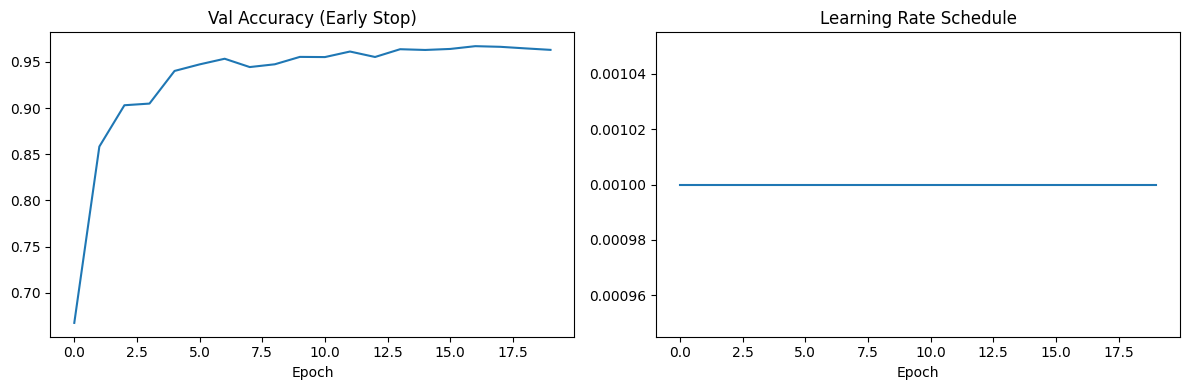

In [17]:
def train_with_early_stopping(model, train_loader, val_loader,
                               epochs=20, lr=0.001, patience=3):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)

    best_val, best_state, wait = 0, None, 0
    history = {'train_loss': [], 'val_acc': [], 'lr': []}

    for epoch in range(epochs):
        model.train()
        for imgs, labels in train_loader:
            imgs = imgs.squeeze(1).to(device); labels = labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(imgs), labels)
            loss.backward()
            optimizer.step()

        model.eval()
        correct = total = 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs = imgs.squeeze(1).to(device); labels = labels.to(device)
                preds = model(imgs).argmax(1)
                correct += (preds == labels).sum().item()
                total   += labels.size(0)
        val_acc = correct / total
        current_lr = optimizer.param_groups[0]['lr']
        history['val_acc'].append(val_acc)
        history['lr'].append(current_lr)
        scheduler.step(1 - val_acc)
        print(f'Epoch {epoch+1:2d} | val_acc={val_acc:.4f} | lr={current_lr:.6f}')

        if val_acc > best_val:
            best_val = val_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f'Early stopping at epoch {epoch+1}')
                break

    model.load_state_dict(best_state)
    return history, best_val


es_model = LSTMModel(hidden_size=128, num_layers=2, dropout=0.3)
es_history, best = train_with_early_stopping(
    es_model, small_loader, mnist_test_loader, epochs=20, patience=3)
print(f'Best val acc: {best:.4f}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(es_history['val_acc']); ax1.set_title('Val Accuracy (Early Stop)'); ax1.set_xlabel('Epoch')
ax2.plot(es_history['lr']);      ax2.set_title('Learning Rate Schedule');    ax2.set_xlabel('Epoch')
plt.tight_layout(); plt.show()

---
## Problem Statement 7 — Comprehensive Comparative Analysis

In [18]:
# Train all final models for comparison
final_models = {
    'Vanilla RNN': VanillaRNNPyTorch(hidden_size=128, num_layers=1),
    'LSTM':        LSTMModel(hidden_size=128, num_layers=1),
    'GRU':         GRUModel(hidden_size=128,  num_layers=1),
    'BiLSTM':      BiLSTMModel(hidden_size=128, merge='concat'),
    'BiGRU':       BiGRUModel(hidden_size=128),
    'CNN+LSTM':    CNNLSTMModel(),
}

comparison = {}
trained_models = {}
for name, model in final_models.items():
    print(f'\n=== {name} ===')
    hist = train_model(model, mnist_train_loader, mnist_test_loader, epochs=5)
    comparison[name] = {
        'val_acc':    hist['val_acc'][-1],
        'train_time': hist['avg_epoch_time'],
        'params':     count_parameters(model),
        'history':    hist,
    }
    trained_models[name] = model

print('\n=== Final Comparison Table ===')
print(f'{"Model":<16} {"Val Acc":>10} {"Params":>10} {"Avg Epoch (s)":>16}')
for k, v in sorted(comparison.items(), key=lambda x: -x[1]['val_acc']):
    print(f'{k:<16} {v["val_acc"]:>10.4f} {v["params"]:>10,} {v["train_time"]:>16.2f}')


=== Vanilla RNN ===
Epoch 1/5 | Train Loss: 0.8893 Acc: 0.6924 | Val Loss: 0.4757 Acc: 0.8425 | Time: 7.6s
Epoch 2/5 | Train Loss: 0.3696 Acc: 0.8896 | Val Loss: 0.2866 Acc: 0.9200 | Time: 7.7s
Epoch 3/5 | Train Loss: 0.2448 Acc: 0.9299 | Val Loss: 0.1885 Acc: 0.9457 | Time: 7.4s
Epoch 4/5 | Train Loss: 0.1984 Acc: 0.9433 | Val Loss: 0.1757 Acc: 0.9521 | Time: 7.6s
Epoch 5/5 | Train Loss: 0.1631 Acc: 0.9537 | Val Loss: 0.1960 Acc: 0.9438 | Time: 7.5s

=== LSTM ===
Epoch 1/5 | Train Loss: 0.5561 Acc: 0.8205 | Val Loss: 0.1541 Acc: 0.9550 | Time: 7.6s
Epoch 2/5 | Train Loss: 0.1376 Acc: 0.9590 | Val Loss: 0.1222 Acc: 0.9619 | Time: 7.6s
Epoch 3/5 | Train Loss: 0.0915 Acc: 0.9728 | Val Loss: 0.0877 Acc: 0.9744 | Time: 7.7s
Epoch 4/5 | Train Loss: 0.0730 Acc: 0.9777 | Val Loss: 0.0748 Acc: 0.9779 | Time: 7.6s
Epoch 5/5 | Train Loss: 0.0582 Acc: 0.9823 | Val Loss: 0.0614 Acc: 0.9814 | Time: 7.6s

=== GRU ===
Epoch 1/5 | Train Loss: 0.6692 Acc: 0.7770 | Val Loss: 0.2035 Acc: 0.9418 | Time: 

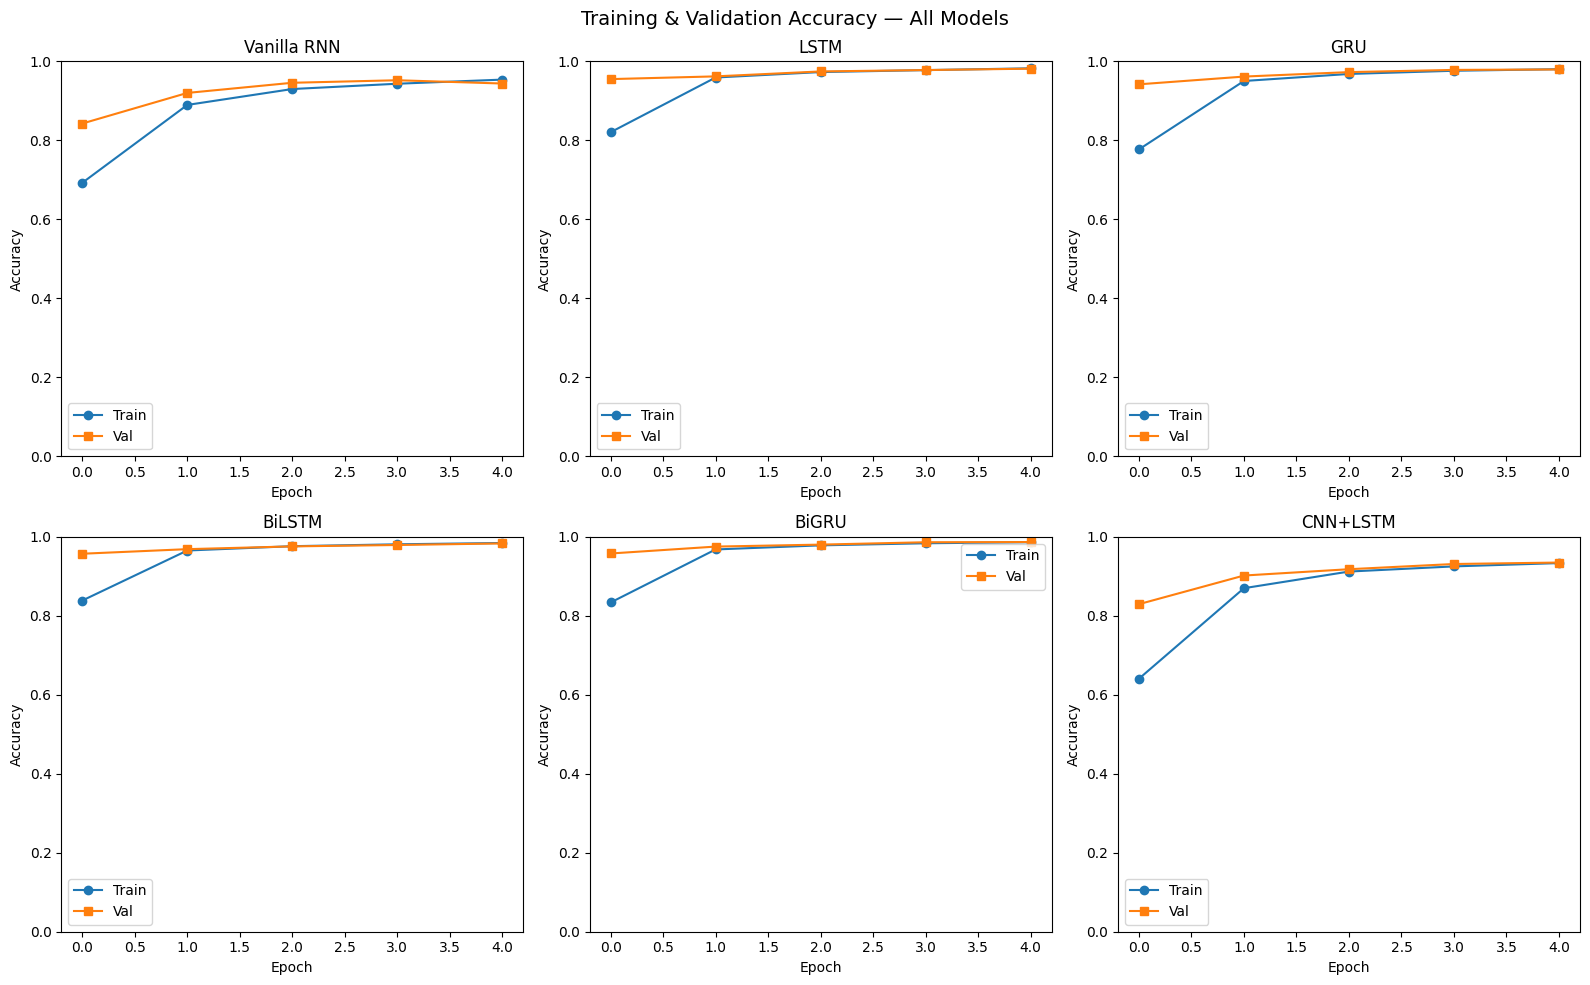

In [19]:
# Training / Validation curves for all models
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, (name, v) in zip(axes.flat, comparison.items()):
    h = v['history']
    ax.plot(h['train_acc'], label='Train', marker='o')
    ax.plot(h['val_acc'],   label='Val',   marker='s')
    ax.set_title(name)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
    ax.legend(); ax.set_ylim(0, 1)
plt.suptitle('Training & Validation Accuracy — All Models', fontsize=14)
plt.tight_layout()
plt.show()

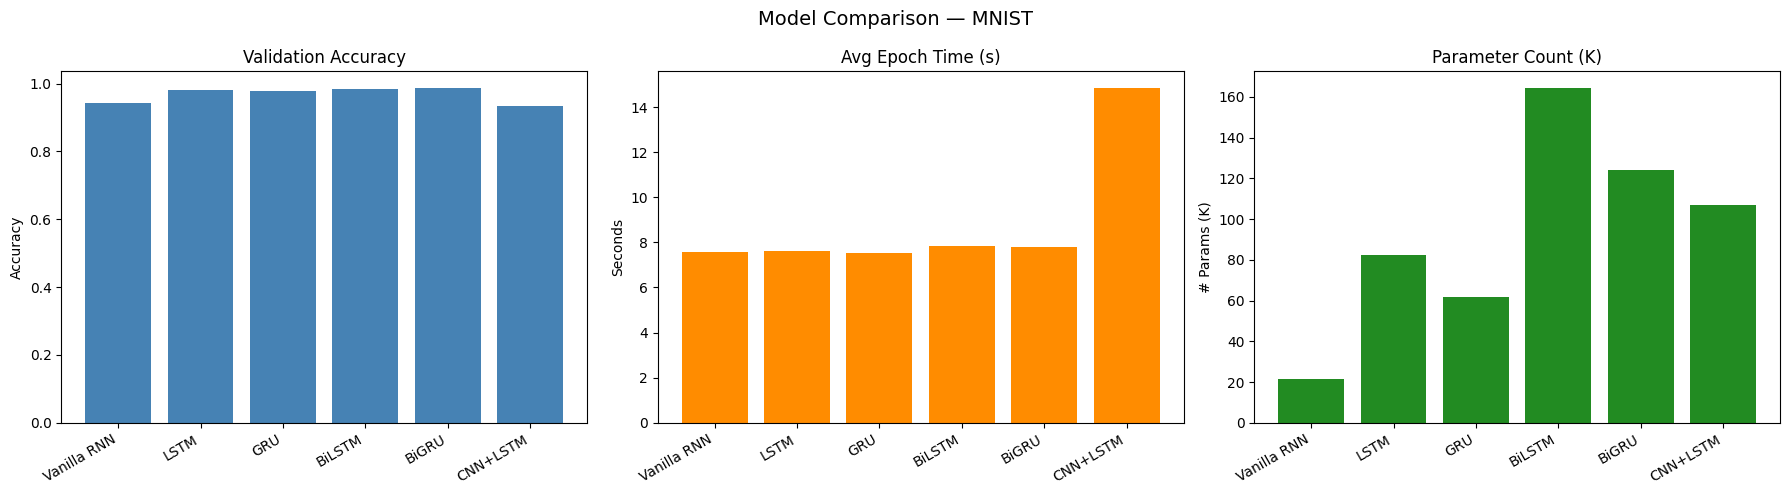

In [20]:
# Comparison bar charts
names   = list(comparison.keys())
accs    = [comparison[n]['val_acc']    for n in names]
times   = [comparison[n]['train_time'] for n in names]
params  = [comparison[n]['params']     for n in names]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
x = np.arange(len(names))

axes[0].bar(x, accs, color='steelblue')
axes[0].set_xticks(x); axes[0].set_xticklabels(names, rotation=30, ha='right')
axes[0].set_title('Validation Accuracy'); axes[0].set_ylabel('Accuracy')

axes[1].bar(x, times, color='darkorange')
axes[1].set_xticks(x); axes[1].set_xticklabels(names, rotation=30, ha='right')
axes[1].set_title('Avg Epoch Time (s)'); axes[1].set_ylabel('Seconds')

axes[2].bar(x, [p/1e3 for p in params], color='forestgreen')
axes[2].set_xticks(x); axes[2].set_xticklabels(names, rotation=30, ha='right')
axes[2].set_title('Parameter Count (K)'); axes[2].set_ylabel('# Params (K)')

plt.suptitle('Model Comparison — MNIST', fontsize=14)
plt.tight_layout()
plt.show()

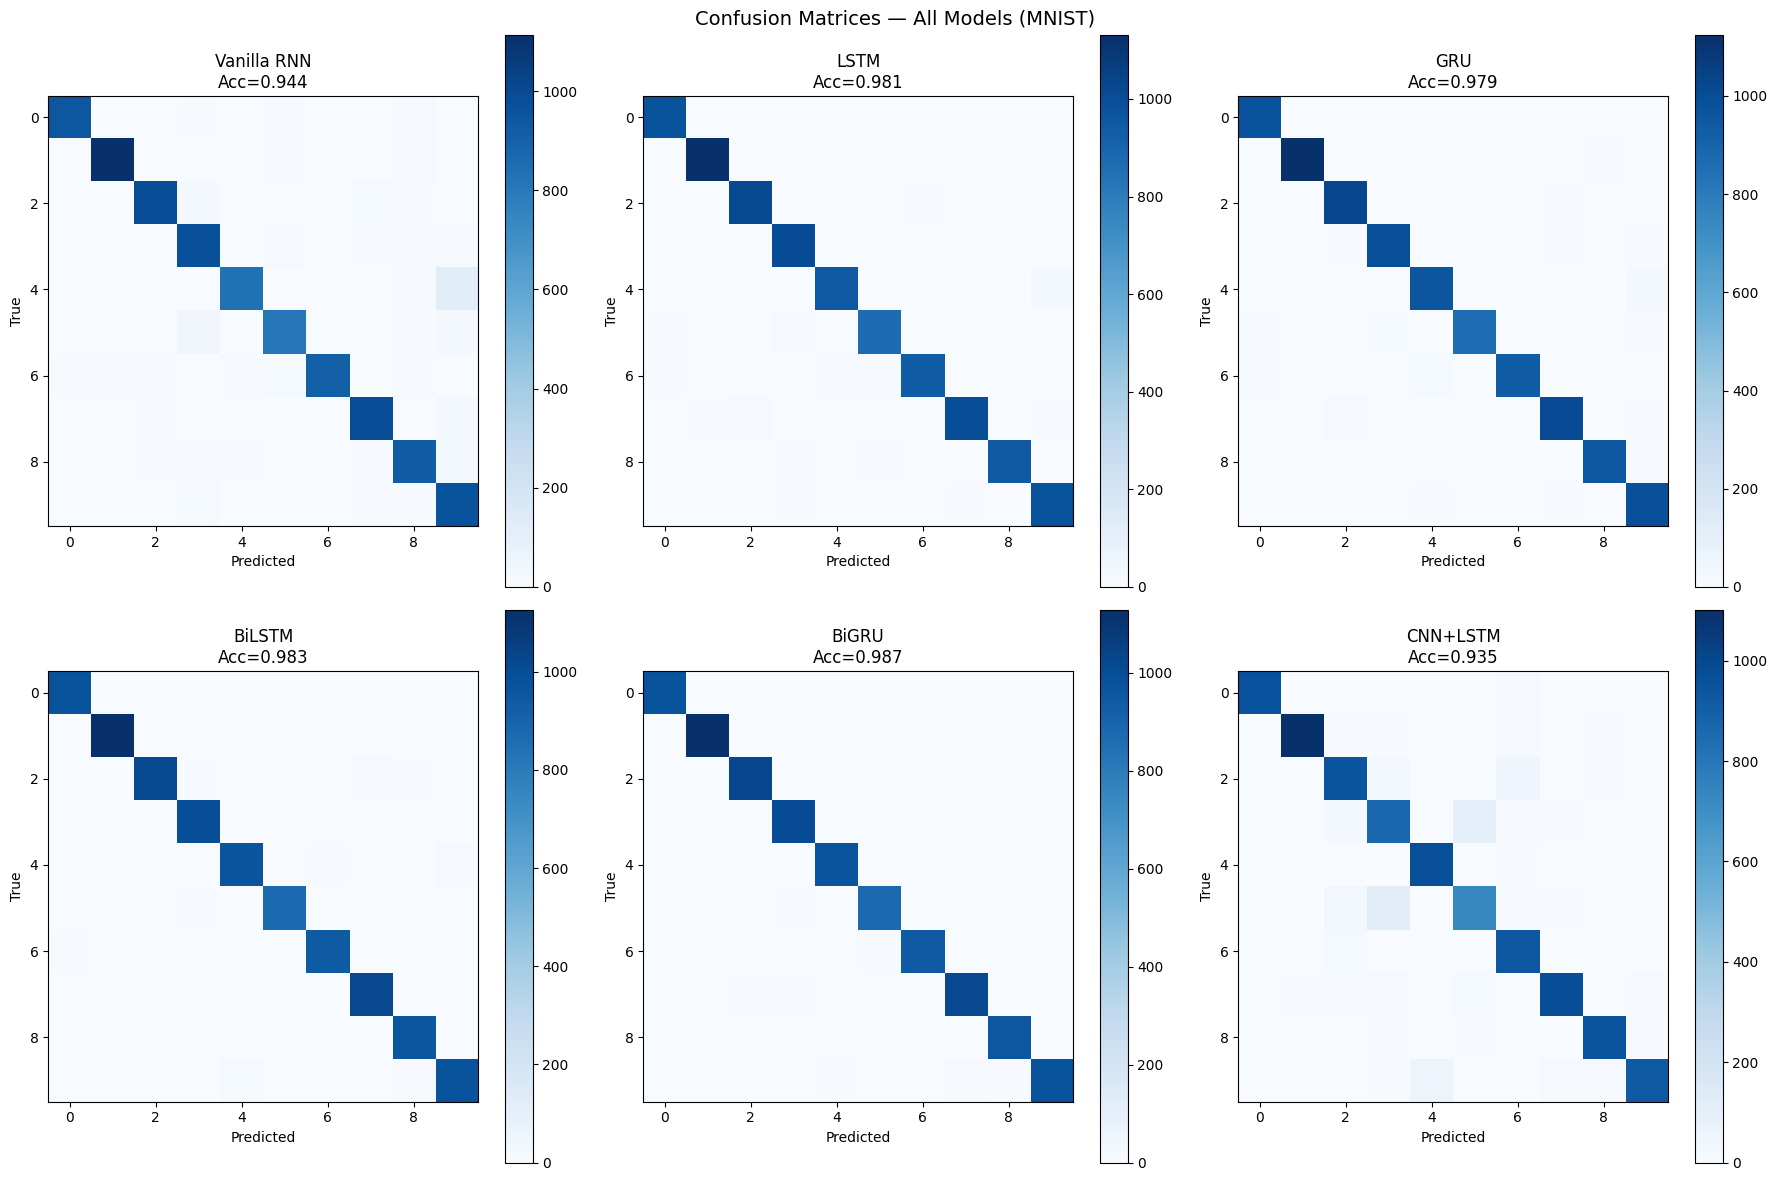

In [21]:
# Confusion Matrices
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
for ax, (name, model) in zip(axes.flat, trained_models.items()):
    preds, labels = evaluate_model(model, mnist_test_loader, num_classes=10)
    cm = confusion_matrix(labels, preds)
    im = ax.imshow(cm, cmap='Blues')
    ax.set_title(f'{name}\nAcc={np.diag(cm).sum()/cm.sum():.3f}')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    fig.colorbar(im, ax=ax)
plt.suptitle('Confusion Matrices — All Models (MNIST)', fontsize=14)
plt.tight_layout()
plt.show()

Running t-SNE...


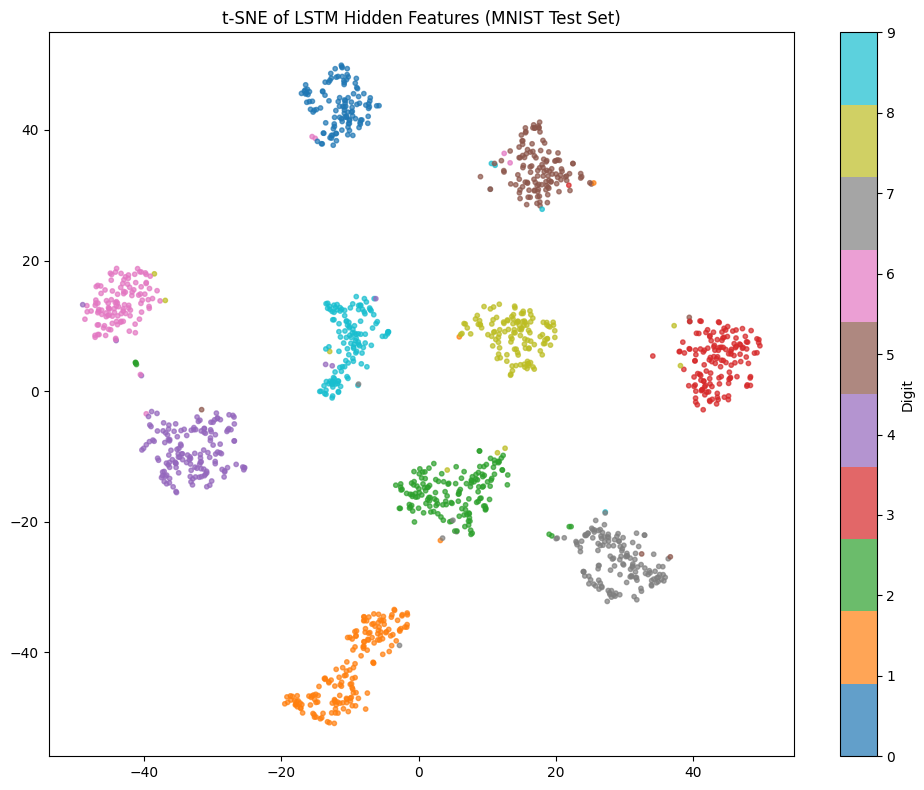

In [22]:
# t-SNE Visualization of LSTM features
class LSTMFeatureExtractor(nn.Module):
    def __init__(self, lstm_model):
        super().__init__()
        self.lstm = lstm_model.lstm

    def forward(self, x):
        _, (hn, _) = self.lstm(x)
        return hn[-1]


feat_model = trained_models['LSTM']
feat_model.eval()
features, all_labels = [], []

with torch.no_grad():
    for i, (imgs, labels) in enumerate(mnist_test_loader):
        if i > 10:
            break
        imgs = imgs.squeeze(1).to(device)
        _, (hn, _) = feat_model.lstm(imgs)
        features.append(hn[-1].cpu().numpy())
        all_labels.extend(labels.numpy())

features = np.vstack(features)
all_labels = np.array(all_labels)

print('Running t-SNE...')
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embeddings = tsne.fit_transform(features)

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(embeddings[:, 0], embeddings[:, 1],
                     c=all_labels, cmap='tab10', alpha=0.7, s=10)
plt.colorbar(scatter, ax=ax, ticks=range(10), label='Digit')
ax.set_title('t-SNE of LSTM Hidden Features (MNIST Test Set)')
plt.tight_layout()
plt.show()

Best model: BiGRU (0.9868 val acc)
Showing first 16 misclassified examples:


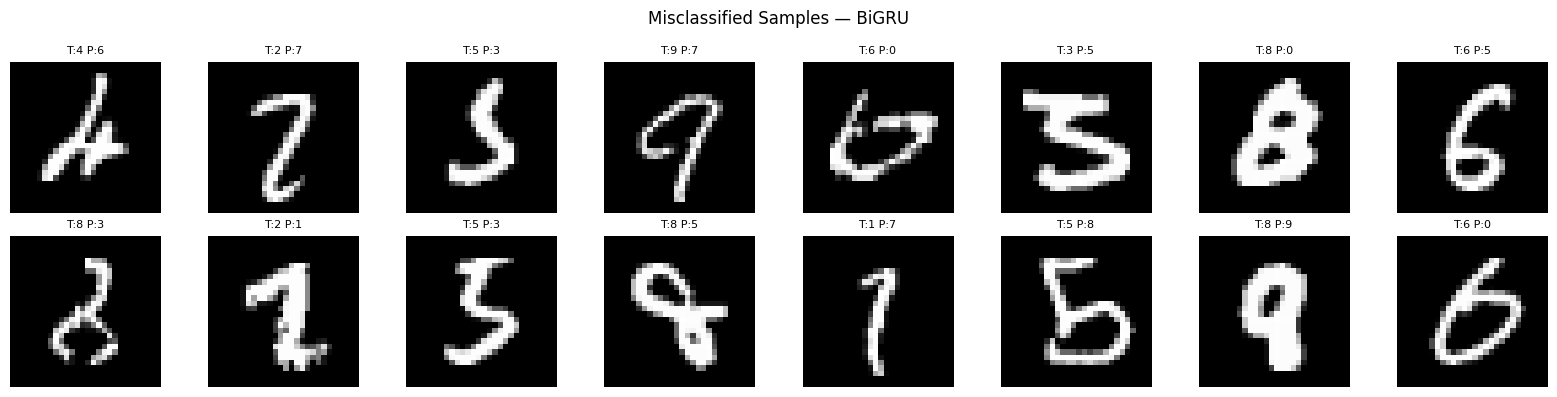

In [23]:
# Misclassified samples analysis
best_model_name = max(comparison, key=lambda k: comparison[k]['val_acc'])
best_model = trained_models[best_model_name]
best_model.eval()

misclassified_imgs, misclassified_true, misclassified_pred = [], [], []
with torch.no_grad():
    for imgs, labels in mnist_test_loader:
        x = imgs.squeeze(1).to(device)
        preds = best_model(x).argmax(1).cpu()
        wrong = preds != labels
        misclassified_imgs.extend(imgs[wrong].numpy())
        misclassified_true.extend(labels[wrong].numpy())
        misclassified_pred.extend(preds[wrong].numpy())
        if len(misclassified_imgs) >= 16:
            break

print(f'Best model: {best_model_name} ({comparison[best_model_name]["val_acc"]:.4f} val acc)')
print(f'Showing first 16 misclassified examples:')

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    if i < len(misclassified_imgs):
        ax.imshow(misclassified_imgs[i].squeeze(), cmap='gray')
        ax.set_title(f'T:{misclassified_true[i]} P:{misclassified_pred[i]}', fontsize=8)
    ax.axis('off')
plt.suptitle(f'Misclassified Samples — {best_model_name}', fontsize=12)
plt.tight_layout()
plt.show()

In [24]:
# Inference time measurement
print('=== Inference Time (per batch of 128) ===')
sample_batch = next(iter(mnist_test_loader))[0].squeeze(1).to(device)
for name, model in trained_models.items():
    model.eval()
    # Warm-up
    with torch.no_grad():
        _ = model(sample_batch)
    t0 = time.time()
    with torch.no_grad():
        for _ in range(50):
            _ = model(sample_batch)
    avg_ms = (time.time() - t0) / 50 * 1000
    print(f'{name:<16} {avg_ms:.2f} ms/batch')

print('\n=== Final Summary ===')
print(f'{"Model":<16} {"Val Acc":>10} {"Params":>10} {"Epoch(s)":>10} {"Notes"}')
notes = {
    'Vanilla RNN': 'Vanishing gradient issues',
    'LSTM':        'Strong long-range memory',
    'GRU':         'Faster, fewer params than LSTM',
    'BiLSTM':      'Bidirectional context',
    'BiGRU':       'Efficient bidirectional',
    'CNN+LSTM':    'Best of spatial + sequential',
}
for k, v in sorted(comparison.items(), key=lambda x: -x[1]['val_acc']):
    print(f'{k:<16} {v["val_acc"]:>10.4f} {v["params"]:>10,} {v["train_time"]:>10.2f}  {notes.get(k,"")}')

=== Inference Time (per batch of 128) ===
Vanilla RNN      0.28 ms/batch
LSTM             0.32 ms/batch
GRU              0.27 ms/batch
BiLSTM           0.33 ms/batch
BiGRU            0.31 ms/batch
CNN+LSTM         3.78 ms/batch

=== Final Summary ===
Model               Val Acc     Params   Epoch(s) Notes
BiGRU                0.9868    123,914       7.79  Efficient bidirectional
BiLSTM               0.9833    164,362       7.83  Bidirectional context
LSTM                 0.9814     82,186       7.63  Strong long-range memory
GRU                  0.9794     61,962       7.54  Faster, fewer params than LSTM
Vanilla RNN          0.9438     21,514       7.58  Vanishing gradient issues
CNN+LSTM             0.9349    106,954      14.84  Best of spatial + sequential
